<a href="https://colab.research.google.com/github/karlositalo/karlos_mbt_test/blob/main/questao_2_2_classificador_bmw10_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Questão 2.2 — Classificador de tipos de carros (BMW-10)

Solução em **PyTorch**, preparada para o Google Colab.

O fluxo executa:

1. download do BMW-10 pelo Kaggle;
2. leitura das informações do arquivo `.mat`;
3. conversão das classes originais em `Classe 3`, `Classe 4`, `Classe 5` e `Outros`;
4. divisão estratificada em treino, validação e teste;
5. treinamento por transferência de aprendizado com MobileNetV2;
6. cálculo de métricas, matriz de confusão e gráficos;
7. salvamento do melhor modelo.

> No Colab, selecione **Ambiente de execução → Alterar tipo de ambiente de execução → GPU** antes do treinamento.


In [ ]:
# Bibliotecas necessárias
!pip -q install kaggle scipy scikit-learn pandas matplotlib pillow

import os
import re
import json
import random
import shutil
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.io import loadmat

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)


PyTorch: 2.11.0+cpu
Dispositivo: cpu


## 1. Download do BMW-10

Crie um token na sua conta do Kaggle e envie o arquivo `kaggle.json` quando solicitado.

O identificador utilizado é:

```text
vikrampunia/bmw10-release
```


In [ ]:
from google.colab import files

DATA_ROOT = Path("/content/bmw10")

if not any(DATA_ROOT.rglob("*.mat")):
    print("Envie o arquivo kaggle.json:")
    uploaded = files.upload()

    if "kaggle.json" not in uploaded:
        raise FileNotFoundError(
            "O arquivo kaggle.json não foi enviado. "
            "Baixe o token da sua conta do Kaggle."
        )

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)

    token_path = kaggle_dir / "kaggle.json"
    shutil.copy("kaggle.json", token_path)
    os.chmod(token_path, 0o600)

    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    !kaggle datasets download         -d vikrampunia/bmw10-release         -p /content/bmw10         --unzip

print("Diretório do dataset:", DATA_ROOT)
print("Arquivos .mat:", len(list(DATA_ROOT.rglob("*.mat"))))


Envie o arquivo kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vikrampunia/bmw10-release
License(s): unknown
100% 1.88G/1.88G [01:33<00:00, 21.5MB/s]

Diretório do dataset: /content/bmw10
Arquivos .mat: 0


In [ ]:
import tarfile

arquivos_tgz = list(DATA_ROOT.glob("*.tgz"))

if not arquivos_tgz:
    print("Nenhum arquivo .tgz encontrado.")
else:
    for arquivo in arquivos_tgz:
        print(f"Extraindo: {arquivo.name}")

        with tarfile.open(arquivo, mode="r:gz") as pacote:
            pacote.extractall(path=DATA_ROOT, filter="data")

    print(f"\nConcluído: {len(arquivos_tgz)} arquivo(s) extraído(s) em {DATA_ROOT}")

Extraindo: cars_test.tgz
Extraindo: cars_train.tgz
Extraindo: bmw10_release.tgz

Concluído: 3 arquivo(s) extraído(s) em /content/bmw10


## 2. Leitura das imagens e das anotações `.mat`

O carregador procura registros contendo campos como `fname`, `filename` ou `image`
e `class` ou `label`. Há também uma alternativa para arquivos `.mat` que armazenam
nomes e rótulos em vetores separados.


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

PATH_KEYWORDS = {
    "fname", "filename", "file_name", "file", "image",
    "image_name", "img", "img_name", "path", "relative_path"
}

LABEL_KEYWORDS = {
    "class", "class_id", "classid", "label", "labels",
    "category", "category_id", "target"
}


def normalize_key(key):
    return re.sub(r"[^a-z0-9_]", "", str(key).lower())


def scalar_string(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="ignore")

    if isinstance(value, str):
        return value

    if isinstance(value, np.ndarray) and value.size == 1:
        return scalar_string(value.reshape(-1)[0])

    return None


def scalar_integer(value):
    if isinstance(value, (int, np.integer)):
        return int(value)

    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return int(value)

    if isinstance(value, np.ndarray) and value.size == 1:
        return scalar_integer(value.reshape(-1)[0])

    return None


def direct_string_list(value):
    if isinstance(value, str):
        return [value]

    if isinstance(value, bytes):
        return [value.decode("utf-8", errors="ignore")]

    if isinstance(value, np.ndarray):
        values = value.reshape(-1).tolist()
    elif isinstance(value, (list, tuple)):
        values = list(value)
    else:
        return []

    result = [scalar_string(item) for item in values]

    if result and all(item is not None for item in result):
        return result

    return []


def direct_integer_list(value):
    if isinstance(value, np.ndarray):
        values = value.reshape(-1).tolist()
    elif isinstance(value, (list, tuple)):
        values = list(value)
    else:
        integer = scalar_integer(value)
        return [] if integer is None else [integer]

    result = [scalar_integer(item) for item in values]

    if result and all(item is not None for item in result):
        return result

    return []


def looks_like_image_reference(text):
    text = str(text).replace("\\", "/")
    suffix = Path(text).suffix.lower()
    return suffix in IMAGE_EXTENSIONS


def extract_pairs_from_structure(root_object):
    """Extrai pares (arquivo da imagem, classe original) da estrutura do .mat."""
    records = []
    visited = set()

    def add_record(image_ref, label):
        image_ref = scalar_string(image_ref)
        label = scalar_integer(label)

        if image_ref is None or label is None:
            return

        if looks_like_image_reference(image_ref):
            records.append((image_ref, label))

    def walk(node):
        node_id = id(node)

        if isinstance(node, (dict, list, tuple, np.ndarray)):
            if node_id in visited:
                return
            visited.add(node_id)

        if isinstance(node, dict):
            normalized = {
                normalize_key(key): value
                for key, value in node.items()
                if not str(key).startswith("__")
            }

            path_value = None
            label_value = None

            for key, value in normalized.items():
                if key in PATH_KEYWORDS and scalar_string(value) is not None:
                    path_value = value

                if key in LABEL_KEYWORDS and scalar_integer(value) is not None:
                    label_value = value

            if path_value is not None and label_value is not None:
                add_record(path_value, label_value)

            path_arrays = []
            label_arrays = []

            for key, value in normalized.items():
                strings = direct_string_list(value)
                integers = direct_integer_list(value)

                if (
                    key in PATH_KEYWORDS
                    and strings
                    and all(looks_like_image_reference(item) for item in strings)
                ):
                    path_arrays.append(strings)

                if key in LABEL_KEYWORDS and integers:
                    label_arrays.append(integers)

            for paths in path_arrays:
                for labels in label_arrays:
                    if len(paths) == len(labels):
                        for image_ref, label in zip(paths, labels):
                            add_record(image_ref, label)

            for value in normalized.values():
                walk(value)

        elif isinstance(node, (list, tuple)):
            for item in node:
                walk(item)

        elif isinstance(node, np.ndarray):
            if node.dtype.names:
                for item in node.reshape(-1):
                    record = {
                        field: item[field]
                        for field in node.dtype.names
                    }
                    walk(record)

            elif node.dtype == object:
                for item in node.reshape(-1):
                    walk(item)

    walk(root_object)

    unique = []
    seen = set()

    for image_ref, label in records:
        key = (str(image_ref), int(label))

        if key not in seen:
            unique.append(key)
            seen.add(key)

    return unique


def collect_numeric_candidates(node, prefix="root"):
    """Localiza vetores numéricos que possam conter os rótulos."""
    candidates = []

    if isinstance(node, dict):
        for key, value in node.items():
            if str(key).startswith("__"):
                continue

            candidates.extend(
                collect_numeric_candidates(
                    value,
                    prefix=f"{prefix}.{key}"
                )
            )

    elif isinstance(node, (list, tuple)):
        try:
            array = np.asarray(node)
        except Exception:
            array = None

        if array is not None and np.issubdtype(array.dtype, np.number):
            flat = array.reshape(-1)

            if flat.size and np.all(np.isfinite(flat)):
                rounded = np.rint(flat).astype(int)

                if np.allclose(flat, rounded):
                    candidates.append((prefix, rounded))

        for index, item in enumerate(node):
            candidates.extend(
                collect_numeric_candidates(
                    item,
                    prefix=f"{prefix}[{index}]"
                )
            )

    elif isinstance(node, np.ndarray):
        if np.issubdtype(node.dtype, np.number):
            flat = node.reshape(-1)

            if flat.size and np.all(np.isfinite(flat)):
                rounded = np.rint(flat).astype(int)

                if np.allclose(flat, rounded):
                    candidates.append((prefix, rounded))

        elif node.dtype == object:
            for index, item in enumerate(node.reshape(-1)):
                candidates.extend(
                    collect_numeric_candidates(
                        item,
                        prefix=f"{prefix}[{index}]"
                    )
                )

    return candidates


def build_image_lookup(image_paths, root):
    by_name = defaultdict(list)
    by_stem = defaultdict(list)
    relative_lookup = {}

    for path in image_paths:
        by_name[path.name.lower()].append(path)
        by_stem[path.stem.lower()].append(path)

        relative = str(path.relative_to(root)).replace("\\", "/").lower()
        relative_lookup[relative] = path

    return by_name, by_stem, relative_lookup


def resolve_image_reference(
    reference,
    root,
    by_name,
    by_stem,
    relative_lookup
):
    normalized = str(reference).strip().replace("\\", "/")
    normalized_lower = normalized.lower().lstrip("./")

    direct = root / normalized

    if direct.exists():
        return direct.resolve()

    if normalized_lower in relative_lookup:
        return relative_lookup[normalized_lower].resolve()

    suffix_matches = [
        path
        for relative, path in relative_lookup.items()
        if relative.endswith(normalized_lower)
    ]

    if len(suffix_matches) == 1:
        return suffix_matches[0].resolve()

    basename = Path(normalized).name.lower()

    if len(by_name[basename]) == 1:
        return by_name[basename][0].resolve()

    stem = Path(normalized).stem.lower()

    if len(by_stem[stem]) == 1:
        return by_stem[stem][0].resolve()

    return None


def load_bmw10_dataframe(dataset_root):
    dataset_root = Path(dataset_root)

    image_paths = sorted(
        path
        for path in dataset_root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    mat_paths = sorted(dataset_root.rglob("*.mat"))

    if not image_paths:
        raise FileNotFoundError(
            f"Nenhuma imagem foi encontrada em {dataset_root}."
        )

    if not mat_paths:
        raise FileNotFoundError(
            f"Nenhum arquivo .mat foi encontrado em {dataset_root}."
        )

    print(f"Imagens encontradas: {len(image_paths)}")
    print(f"Arquivos .mat encontrados: {len(mat_paths)}")

    by_name, by_stem, relative_lookup = build_image_lookup(
        image_paths,
        dataset_root
    )

    resolved_records = []
    loaded_mat_objects = []

    for mat_path in mat_paths:
        try:
            mat_data = loadmat(
                mat_path,
                simplify_cells=True
            )
        except NotImplementedError as error:
            raise RuntimeError(
                f"O arquivo {mat_path} usa MAT v7.3/HDF5. "
                "Adapte a leitura com h5py."
            ) from error

        loaded_mat_objects.append((mat_path, mat_data))

        visible_keys = [
            key for key in mat_data.keys()
            if not key.startswith("__")
        ]

        print(f"\n{mat_path.name}: {visible_keys}")

        pairs = extract_pairs_from_structure(mat_data)

        for image_ref, label in pairs:
            resolved_path = resolve_image_reference(
                image_ref,
                dataset_root,
                by_name,
                by_stem,
                relative_lookup
            )

            if resolved_path is not None:
                resolved_records.append(
                    {
                        "filepath": str(resolved_path),
                        "original_label": int(label),
                        "mat_file": mat_path.name,
                    }
                )

    records_df = pd.DataFrame(resolved_records)

    if not records_df.empty:
        records_df = (
            records_df
            .drop_duplicates(subset="filepath")
            .reset_index(drop=True)
        )

    if records_df.empty:
        numeric_candidates = []

        for mat_path, mat_data in loaded_mat_objects:
            for candidate_name, values in collect_numeric_candidates(mat_data):
                values = np.asarray(values).reshape(-1)

                if len(values) != len(image_paths):
                    continue

                unique_values = np.unique(values)

                if (
                    unique_values.size <= 10
                    and unique_values.min() >= 0
                    and unique_values.max() <= 10
                ):
                    score = 0
                    name_lower = candidate_name.lower()

                    if "label" in name_lower or "class" in name_lower:
                        score += 10

                    if 3 in unique_values and 4 in unique_values and 5 in unique_values:
                        score += 5

                    numeric_candidates.append(
                        (
                            score,
                            mat_path.name,
                            candidate_name,
                            values.astype(int)
                        )
                    )

        if not numeric_candidates:
            raise RuntimeError(
                "Não foi possível localizar pares imagem/classe no arquivo .mat. "
                "Execute a célula de inspeção e ajuste PATH_KEYWORDS e "
                "LABEL_KEYWORDS aos nomes de campos encontrados."
            )

        numeric_candidates.sort(key=lambda item: item[0], reverse=True)
        _, mat_name, candidate_name, labels = numeric_candidates[0]

        print(
            "\nAlternativa utilizada:",
            mat_name,
            candidate_name
        )

        records_df = pd.DataFrame(
            {
                "filepath": [str(path.resolve()) for path in image_paths],
                "original_label": labels,
                "mat_file": mat_name,
            }
        )

    unique_labels = sorted(records_df["original_label"].unique())

    if unique_labels and min(unique_labels) == 0 and max(unique_labels) <= 9:
        print("Rótulos 0..9 detectados; convertendo para 1..10.")
        records_df["original_label"] += 1

    return records_df


df = load_bmw10_dataframe(DATA_ROOT)

print("\nAmostra das anotações:")
display(df.head())

print("\nClasses originais encontradas:")
print(sorted(df["original_label"].unique()))


Imagens encontradas: 16697
Arquivos .mat encontrados: 1

bmw10_annos.mat: ['train_indices', 'test_indices', 'annos']

Amostra das anotações:


,filepath,original_label,mat_file
0,/content/bmw10/bmw10_ims/10/150302307.thumb.jpg,9,bmw10_annos.mat
1,/content/bmw10/bmw10_ims/10/150302397.jpg,9,bmw10_annos.mat
2,/content/bmw10/bmw10_ims/10/150302515.jpg,9,bmw10_annos.mat
3,/content/bmw10/bmw10_ims/10/150302647.jpg,9,bmw10_annos.mat
4,/content/bmw10/bmw10_ims/10/150302686.jpg,9,bmw10_annos.mat



Classes originais encontradas:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## 3. Criação da classe `Outros`

As classes originais 3, 4 e 5 são mantidas. Todas as demais são agrupadas em
`Outros`.

Como `Outros` pode ficar maior que as três classes específicas, o código não
descarta imagens: ele calcula pesos de classe usando somente o conjunto de treino.


target_name
Outros      360
Classe 5     52
Classe 3     50
Classe 4     50
Name: count, dtype: int64


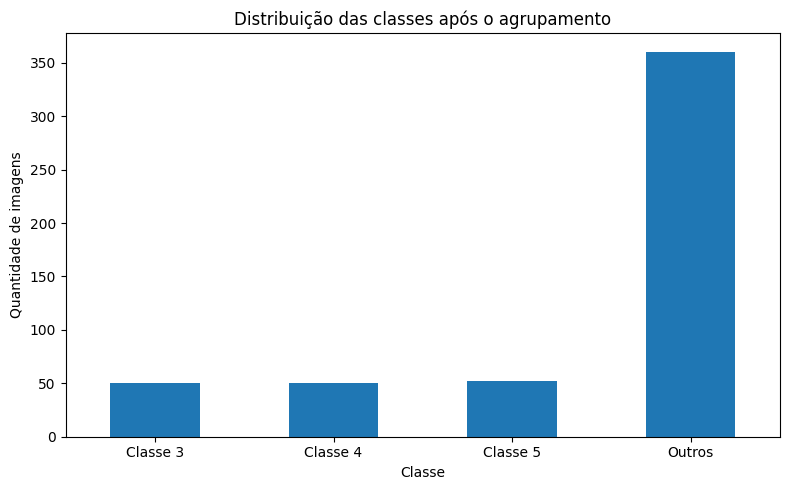

In [ ]:
CLASS_NAMES = [
    "Classe 3",
    "Classe 4",
    "Classe 5",
    "Outros",
]

CLASS_TO_ID = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}


def remap_label(original_label):
    original_label = int(original_label)

    if original_label in {3, 4, 5}:
        return f"Classe {original_label}"

    return "Outros"


df["target_name"] = df["original_label"].map(remap_label)
df["target_id"] = df["target_name"].map(CLASS_TO_ID)

if df["target_id"].isna().any():
    raise RuntimeError("Há rótulos sem mapeamento.")

print(df["target_name"].value_counts())

plt.figure(figsize=(8, 5))
df["target_name"].value_counts().reindex(CLASS_NAMES).plot(kind="bar")
plt.title("Distribuição das classes após o agrupamento")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Divisão estratificada

Proporção utilizada: 70% treino, 15% validação e 15% teste.


In [ ]:
class_counts = df["target_name"].value_counts()

if (class_counts < 4).any():
    raise ValueError(
        "Cada classe precisa ter pelo menos quatro imagens para a "
        "divisão estratificada. Contagens:\n"
        + class_counts.to_string()
    )

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["target_id"],
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["target_id"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Treino:", len(train_df))
print("Validação:", len(validation_df))
print("Teste:", len(test_df))

split_distribution = pd.DataFrame(
    {
        "Treino": train_df["target_name"].value_counts(),
        "Validação": validation_df["target_name"].value_counts(),
        "Teste": test_df["target_name"].value_counts(),
    }
).reindex(CLASS_NAMES)

display(split_distribution)


Treino: 358
Validação: 77
Teste: 77


,Treino,Validação,Teste
target_name,,,
Classe 3,35,7,8
Classe 4,35,8,7
Classe 5,36,8,8
Outros,252,54,54


## 5. Preparação das imagens

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.75, 1.00)
        ),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.15
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class CarDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = row["filepath"]
        label = int(row["target_id"])

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image = self.transform(image)
        except Exception as error:
            raise RuntimeError(
                f"Erro ao abrir a imagem: {image_path}"
            ) from error

        return image, label


train_dataset = CarDataset(train_df, train_transform)
validation_dataset = CarDataset(
    validation_df,
    evaluation_transform
)
test_dataset = CarDataset(test_df, evaluation_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

batch_images, batch_labels = next(iter(train_loader))

print("Formato das imagens:", batch_images.shape)
print("Formato dos rótulos:", batch_labels.shape)


Formato das imagens: torch.Size([32, 3, 224, 224])
Formato dos rótulos: torch.Size([32])


## 6. MobileNetV2 com transferência de aprendizado

In [ ]:
weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

for parameter in model.features.parameters():
    parameter.requires_grad = False

input_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(input_features, len(CLASS_NAMES)),
)

model = model.to(DEVICE)

train_labels = train_df["target_id"].to_numpy()

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels,
)

class_weights = torch.tensor(
    balanced_weights,
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

print("Pesos das classes:")
for class_name, weight in zip(CLASS_NAMES, balanced_weights):
    print(f"{class_name}: {weight:.4f}")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 85.2MB/s]


Pesos das classes:
Classe 3: 2.5571
Classe 4: 2.5571
Classe 5: 2.4861
Outros: 0.3552


## 7. Treinamento

In [ ]:
def run_epoch(model, data_loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

    return (
        total_loss / total_examples,
        total_correct / total_examples,
    )


def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    checkpoint_path,
    early_stopping_patience=4,
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }

    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        validation_loss, validation_accuracy = run_epoch(
            model,
            validation_loader,
            criterion,
            optimizer=None,
        )

        scheduler.step(validation_loss)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        print(
            f"Época {epoch:02d}/{epochs} | "
            f"loss treino: {train_loss:.4f} | "
            f"acc treino: {train_accuracy:.4f} | "
            f"loss val: {validation_loss:.4f} | "
            f"acc val: {validation_accuracy:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print("Early stopping acionado.")
                break

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    )

    return history


CHECKPOINT_PATH = "/content/melhor_bmw10_mobilenetv2.pt"

history = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=15,
    checkpoint_path=CHECKPOINT_PATH,
)


Época 01/15 | loss treino: 1.4599 | acc treino: 0.3156 | loss val: 1.3644 | acc val: 0.5714
Época 02/15 | loss treino: 1.3166 | acc treino: 0.4078 | loss val: 1.2827 | acc val: 0.5584
Época 03/15 | loss treino: 1.2427 | acc treino: 0.6117 | loss val: 1.2436 | acc val: 0.6494
Época 04/15 | loss treino: 1.1587 | acc treino: 0.5838 | loss val: 1.2142 | acc val: 0.5584
Época 05/15 | loss treino: 1.1246 | acc treino: 0.6536 | loss val: 1.1941 | acc val: 0.7273
Época 06/15 | loss treino: 1.0714 | acc treino: 0.6257 | loss val: 1.1669 | acc val: 0.4935
Época 07/15 | loss treino: 1.0332 | acc treino: 0.6229 | loss val: 1.1470 | acc val: 0.5325
Época 08/15 | loss treino: 1.0109 | acc treino: 0.7235 | loss val: 1.1417 | acc val: 0.6364
Época 09/15 | loss treino: 1.0040 | acc treino: 0.6369 | loss val: 1.1326 | acc val: 0.4416
Época 10/15 | loss treino: 0.9413 | acc treino: 0.6313 | loss val: 1.1218 | acc val: 0.4156
Época 11/15 | loss treino: 0.9296 | acc treino: 0.6648 | loss val: 1.1028 | acc 

## 8. Curvas de aprendizado

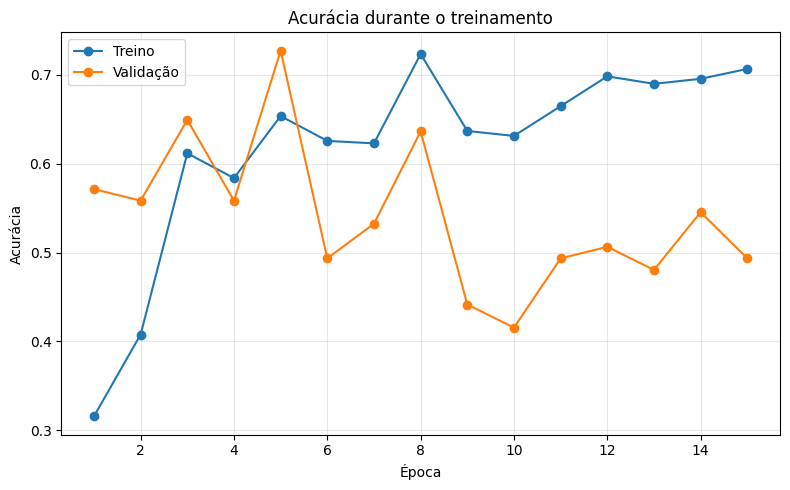

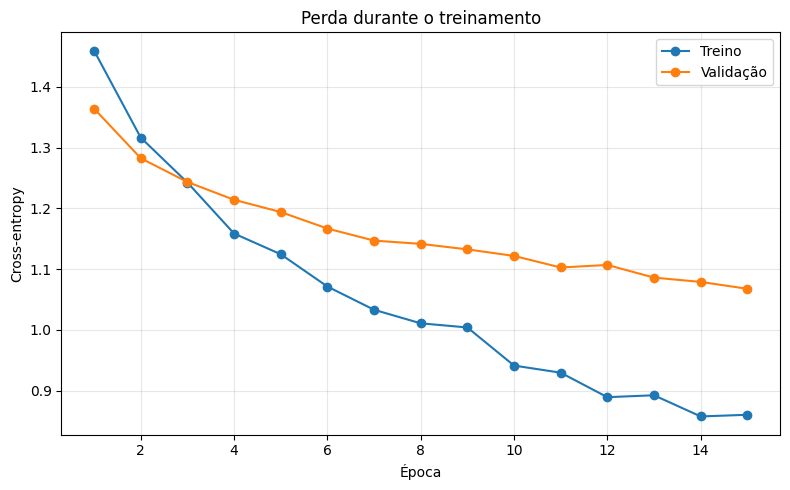

In [ ]:
epochs_completed = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history["train_accuracy"],
    marker="o",
    label="Treino",
)
plt.plot(
    epochs_completed,
    history["validation_accuracy"],
    marker="o",
    label="Validação",
)
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_completed,
    history["train_loss"],
    marker="o",
    label="Treino",
)
plt.plot(
    epochs_completed,
    history["validation_loss"],
    marker="o",
    label="Validação",
)
plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Cross-entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Ajuste fino opcional

In [ ]:
for parameter in model.features[-3:].parameters():
    parameter.requires_grad = True

fine_tune_optimizer = torch.optim.AdamW(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4,
)

fine_tune_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

fine_tune_history = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=fine_tune_optimizer,
    scheduler=fine_tune_scheduler,
    epochs=6,
    checkpoint_path=CHECKPOINT_PATH,
    early_stopping_patience=3,
)


Época 01/6 | loss treino: 0.8045 | acc treino: 0.6872 | loss val: 1.0596 | acc val: 0.5065
Época 02/6 | loss treino: 0.8201 | acc treino: 0.6536 | loss val: 1.0576 | acc val: 0.4935
Época 03/6 | loss treino: 0.7739 | acc treino: 0.6844 | loss val: 1.0535 | acc val: 0.4935
Época 04/6 | loss treino: 0.7816 | acc treino: 0.6955 | loss val: 1.0520 | acc val: 0.5195
Época 05/6 | loss treino: 0.7936 | acc treino: 0.7039 | loss val: 1.0678 | acc val: 0.5195
Época 06/6 | loss treino: 0.8028 | acc treino: 0.7263 | loss val: 1.0483 | acc val: 0.5325


## 10. Avaliação no conjunto de teste

In [ ]:
def predict_loader(model, data_loader):
    model.eval()

    true_labels = []
    predicted_labels = []
    probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)

            logits = model(images)
            batch_probabilities = torch.softmax(logits, dim=1)
            batch_predictions = batch_probabilities.argmax(dim=1)

            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(
                batch_predictions.cpu().numpy().tolist()
            )
            probabilities.extend(
                batch_probabilities.cpu().numpy().tolist()
            )

    return (
        np.asarray(true_labels),
        np.asarray(predicted_labels),
        np.asarray(probabilities),
    )


test_loss, test_accuracy = run_epoch(
    model,
    test_loader,
    criterion,
    optimizer=None,
)

y_true, y_pred, y_probability = predict_loader(
    model,
    test_loader
)

print(f"Loss de teste: {test_loss:.4f}")
print(f"Acurácia de teste: {test_accuracy:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()

display(
    report_df.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        }
    )
)


Loss de teste: 0.9222
Acurácia de teste: 0.6104


,precision,recall,f1-score,support
Classe 3,0.3636,1.0000,0.5333,8
Classe 4,0.4167,0.7143,0.5263,7
Classe 5,0.3333,0.5000,0.4000,8
Outros,0.9677,0.5556,0.7059,54
accuracy,0.6104,0.6104,0.6104,1
macro avg,0.5203,0.6925,0.5414,77
weighted avg,0.7890,0.6104,0.6399,77


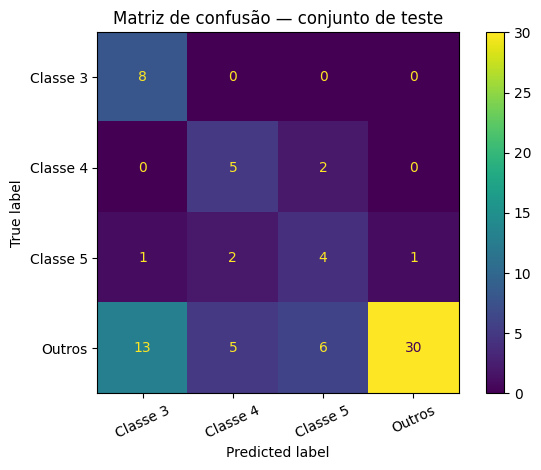

In [ ]:
matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(CLASS_NAMES)),
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)

display_matrix.plot(
    values_format="d",
    xticks_rotation=25,
)

plt.title("Matriz de confusão — conjunto de teste")
plt.tight_layout()
plt.show()


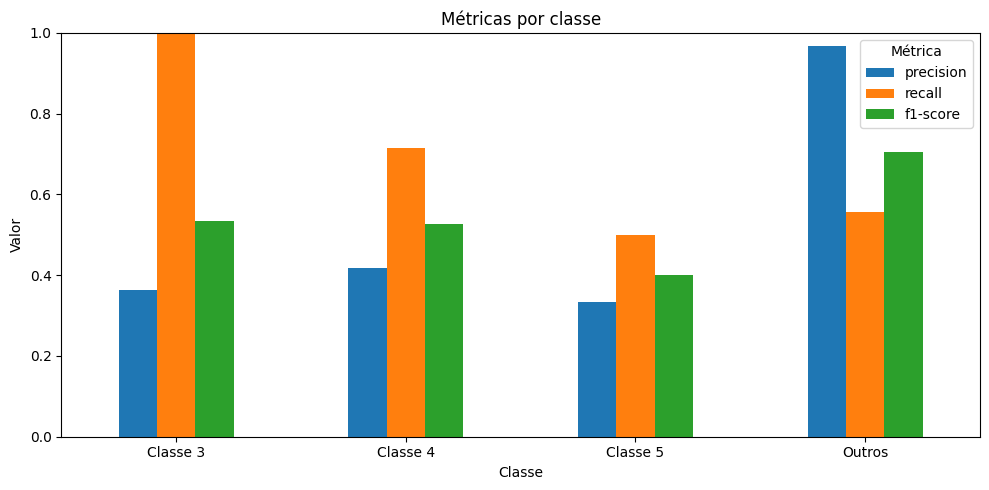

In [ ]:
class_metrics = (
    report_df
    .loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
)

class_metrics.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Métricas por classe")
plt.xlabel("Classe")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


## 11. Salvamento do modelo e dos resultados

In [ ]:
FINAL_MODEL_PATH = "/content/bmw10_mobilenetv2_final.pt"
REPORT_PATH = "/content/metricas_bmw10.csv"
CLASS_MAP_PATH = "/content/classes_bmw10.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "image_size": IMAGE_SIZE,
        "architecture": "MobileNetV2",
    },
    FINAL_MODEL_PATH,
)

report_df.to_csv(REPORT_PATH)

with open(CLASS_MAP_PATH, "w", encoding="utf-8") as file:
    json.dump(
        {
            str(index): class_name
            for index, class_name in enumerate(CLASS_NAMES)
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Modelo:", FINAL_MODEL_PATH)
print("Métricas:", REPORT_PATH)
print("Mapa de classes:", CLASS_MAP_PATH)

# Para baixar:
# files.download(FINAL_MODEL_PATH)
# files.download(REPORT_PATH)
# files.download(CLASS_MAP_PATH)


Modelo: /content/bmw10_mobilenetv2_final.pt
Métricas: /content/metricas_bmw10.csv
Mapa de classes: /content/classes_bmw10.json
